# 🏗 Анализ рынка недвижимости Турции
### 👥 Авторы: Тимур Еникеев и Гареев Рустам
📅 **Дата:** 2026

---
**🎯 Цель проекта:** 
Провести полный разведочный анализ данных (EDA), очистить датасет, сгенерировать новые признаки и подготовить данные к обучению регрессионных моделей для прогнозирования стоимости недвижимости.

**📑 Этапы работы:**
1. ️‍♂️ **EDA** — исследование структуры, распределений, пропусков, корреляций
2.  **Предобработка** — очистка, кодирование, масштабирование, Feature Engineering
3. 🤖 **Моделирование** — обучение, подбор гиперпараметров, выбор лучшей модели
4.  **Применение** — сохранение модели для деплоя в приложение

## 📖 Источник данных

Датасет предоставлен турецкой платформой недвижимости **Zingat.com** 
(https://www.zingat.com) — крупнейший портал по продаже и аренде 
недвижимости в Турции.

**Период сбора:** 2018–2019 гг.  
**Объём:** ~403 000 объявлений  
**География:** вся Турция (Стамбул, Анкара, Измир и др.)  
**Целевая переменная:** `price` — цена объекта в турецких лирах (TRY)

Данные получены в рамках соревнования по прогнозированию стоимости 
недвижимости. Словарь признаков описан в файле `zingat_data_info.docx`.


### 📍 Локация
*   **`city`** — Город, в котором находится объект (например, Стамбул, Анкара, Измир).
*   **`district`** — Район города.
*   **`neighborhood`** — Микрорайон или квартал.
*   *(Примечание: эти три признака обычно извлекаются из полного адреса `address`, который сам по себе в модель не передается из-за слишком большого количества уникальных значений).*

### 🏠 Характеристики объекта
*   **`type`** — Глобальный тип недвижимости (в данном датасете почти везде "Жильё").
*   **`sub_type`** — Конкретный подтип недвижимости (Квартира, Вилла, Отдельный дом, Резиденция, Дача и т.д.).
*   **`room_count`** — Планировка/количество комнат в турецком формате (например, "3+1" означает 3 спальни + 1 гостиная). *В процессе обработки обычно преобразуется в числовой признак `rooms_numeric` (сумма цифр, т.е. 4).*
*   **`size`** — Общая площадь объекта в квадратных метрах (м²).
*   **`building_age`** — Возраст здания в годах. Может быть указан как конкретное число или диапазон (например, "0", "6-10", "20 и более"). *Преобразуется в числовое значение (середина диапазона или граничное значение).*
*   **`total_floor_count`** — Общее количество этажей в здании.
*   **`floor_no`** — Номер этажа, на котором находится конкретный объект. Может содержать специфические значения, такие как "Zemin kat" (цокольный/первый этаж) или "Çatı Katı" (мансардный/последний этаж).
*   **`heating_type`** — Тип системы отопления (например, Kombi/Doğalgaz — индивидуальный газовый котел, Klima — кондиционер, Merkezi Sistem — центральное отопление, Soba — печное).

### 💰 Финансы и сделка
*   **`listing_type`** — Тип сделки или размещения (Продажа, Долгосрочная аренда, Аренда на день/посуточно).
*   **`price`** — Стоимость объекта. Является **целевой переменной** (то, что мы предсказываем). *В процессе обработки преобразуется в `log_price` (логарифм цены) для улучшения работы моделей.*
*   **`price_currency`** — Валюта, в которой указана цена (в основном TRY — турецкая лира, иногда встречается EUR или USD).

### 📅 Временные метки и статистика
*   **`id`** — Уникальный идентификатор объявления (удаляется или не используется при обучении модели, так как не несет смысловой нагрузки).
*   **`start_date`** — Дата размещения объявления на сайте.
*   **`end_date`** — Дата снятия объявления с публикации (может быть пустым, если объявление еще активно).
*   **`tom`** (Time On Market) — Срок экспозиции. Количество дней, которое объявление провисело на сайте до снятия или до момента выгрузки данных.

---

# Прогнозирование стоимости недвижимости в Турции: полный цикл анализа данных

## 1. Общие сведения о проекте

Настоящий проект посвящён построению регрессионной модели для прогнозирования стоимости объектов недвижимости на рынке Турции. Работа выполнена в рамках учебного задания и охватывает полный цикл анализа данных: от первичного исследования (EDA) до построения, валидации и сохранения финальной модели машинного обучения.

**Актуальность задачи.** Рынок недвижимости Турции характеризуется высокой волатильностью цен, значительной региональной дифференциацией и большим количеством факторов, влияющих на стоимость объекта. Автоматизированное прогнозирование стоимости позволяет:
- снизить информационную асимметрию между продавцами и покупателями;
- повысить эффективность работы риелторских агентств;
- обеспечить аналитическую поддержку для инвестиционных решений;
- создать основу для автоматизированных систем оценки (AVM — Automated Valuation Models).

**Целевая переменная.** В качестве целевой переменной выступает `price` — цена объекта в турецких лирах (TRY). Переменная имеет ярко выраженную правостороннюю асимметрию, что требует применения логарифмического преобразования перед обучением моделей.

**Источник данных.** Датасет предоставлен турецкой платформой недвижимости Zingat.com и содержит информацию о 403 487 объявлениях за период 2018–2019 годов. Данные охватывают всю территорию Турции и включают как объекты продажи, так и объекты аренды.

## 2. Структура проекта

Проект структурирован в соответствии с требованиями технического задания и включает четыре последовательных этапа:

| Этап | Содержание | Результат |
|------|-----------|-----------|
| 1. Исследование данных (EDA) | Анализ структуры, распределений, пропусков, корреляций | Сформулированные гипотезы |
| 2. Предварительная обработка | Очистка, кодирование, Feature Engineering, масштабирование | Готовый к моделированию датасет |
| 3. Построение моделей | Обучение, подбор гиперпараметров, валидация | Финальная модель (Random Forest) |
| 4. Применение | Сохранение модели, подготовка к деплою | Файлы `best_model_pipeline.pkl`, `feature_schema.pkl` |

## 3. Технологический стек

- **Язык программирования:** Python 3.13
- **Среда выполнения:** Jupyter Notebook
- **Библиотеки анализа данных:** pandas, numpy, scipy, statsmodels
- **Библиотеки визуализации:** matplotlib, seaborn
- **Библиотеки машинного обучения:** scikit-learn
- **Сохранение моделей:** joblib

## 4. Ключевые методологические решения

1. **Логарифмирование целевой переменной.** Исходное распределение цены имеет экстремальную асимметрию (skew ≈ 308). Применение преобразования `log1p` снижает асимметрию до −0.81, что делает распределение близким к нормальному и существенно улучшает качество линейных моделей.

2. **Разбиение данных 70/15/15.** Данные разделены на обучающую (70%), валидационную (15%) и тестовую (15%) выборки с фиксацией случайного состояния (`random_state=42`) для воспроизводимости результатов.

3. **Обучение препроцессинга только на train.** Все трансформации (импутация, масштабирование, One-Hot Encoding) обучаются исключительно на обучающей выборке, что исключает утечку данных (data leakage).

4. **Выбор Random Forest в качестве финальной модели.** По результатам сравнения трёх моделей разной природы (Ridge, Decision Tree, Random Forest) модель Random Forest демонстрирует наилучшее качество на валидационной выборке (MAE_log = 0.241, R²_log = 0.974).

---

## Выводы по введению

Проект построен на методологически корректной основе: соблюдены принципы разделения данных, исключена утечка информации, применено адекватное преобразование целевой переменной. Выбор трёх моделей разной природы (линейная, дерево, ансамбль) позволяет провести содержательное сравнение и обосновать выбор финального решения.

## 📦 1. Импорт библиотек и настройка окружения

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import joblib
import warnings
from scipy.stats import skew, kurtosis
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid", palette="Set2")
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['font.family'] = 'DejaVu Sans'

## 📂 2. Загрузка данных и первичный осмотр

In [10]:
# Загрузка датасета
# Поместите real_estate_data.csv в ту же папку, что и ноутбук.
from pathlib import Path
import pandas as pd

DATA_PATH = Path(r"C:\Users\Рустам\Desktop\turkey\real_estate_data.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Не найден файл {DATA_PATH.resolve()}. "
        "Положите real_estate_data.csv рядом с ноутбуком."
    )

df = pd.read_csv(DATA_PATH, low_memory=False)

print(df.columns.tolist())

print(f"Размерность: {df.shape[0]} строк x {df.shape[1]} столбцов")
print(f"\nДубликатов: {df.duplicated().sum()}")
print(f"\nТипы данных:")
print(df.dtypes.value_counts())
display(df.head(3))

print("Последние 3 строки:")
display(df.tail(3))

print("\nСлучайная строка:")
display(df.sample(1, random_state=42))

print("Уникальных значений по категориальным признакам:")
for col in ['city', 'district', 'neighborhood', 'listing_type', 'type', 'sub_type', 'heating_type', 'room_count']:
    if col in df.columns:
        print(f"  {col}: {df[col].nunique()} уникальных значений")

['id', 'type', 'sub_type', 'start_date', 'end_date', 'listing_type', 'tom', 'building_age', 'total_floor_count', 'floor_no', 'room_count', 'size', 'heating_type', 'price', 'price_currency', 'city', 'district', 'neighborhood']
Размерность: 403487 строк x 18 столбцов

Дубликатов: 0

Типы данных:
object     14
int64       2
float64     2
Name: count, dtype: int64


,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,heating_type,price,price_currency,city,district,neighborhood
0,1,Жильё,Резиденция,12/10/18,1/9/19,Аренда,30,0,20 и более,2,2+1,90.0,Фанкойл,3500.0,TRY,Стамбул,Kartal,Kordonboyu
1,2,Жильё,Квартира,2/13/19,NaN,Продажа,14,0,20 и более,20 и более,1+0,43.0,Фанкойл,490000.0,TRY,Стамбул,Kartal,Kordonboyu
2,3,Жильё,Квартира,10/9/18,11/8/18,Продажа,30,0,1,Высокий первый этаж,2+1,NaN,Фанкойл,155000.0,TRY,Текирдаг,Çorlu,Reşadiye


Последние 3 строки:


,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,heating_type,price,price_currency,city,district,neighborhood
403484,403485,Жильё,Квартира,11/22/18,NaN,Продажа,97,NaN,NaN,NaN,1+1,NaN,Нет,48000.0,EUR,Анталья,Alanya,Saray
403485,403486,Жильё,Квартира,2/21/19,NaN,Аренда,6,NaN,NaN,NaN,2+1,2.0,Нет,900.0,TRY,Айдын,Kuşadası,Türkmen
403486,403487,Жильё,Квартира,1/15/19,1/18/19,Продажа,3,NaN,NaN,NaN,3+1,140.0,Нет,210000.0,TRY,Кайсери,Melikgazi,Alpaslan



Случайная строка:


,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,heating_type,price,price_currency,city,district,neighborhood
60623,60624,Жильё,Квартира,11/20/18,2/23/19,Продажа,95,6-10 лет,5,1,2+1,120.0,Klima,240000.0,TRY,Анталья,Alanya,Oba


Уникальных значений по категориальным признакам:
  city: 82 уникальных значений
  district: 526 уникальных значений
  neighborhood: 4834 уникальных значений
  listing_type: 3 уникальных значений
  type: 1 уникальных значений
  sub_type: 12 уникальных значений
  heating_type: 16 уникальных значений
  room_count: 37 уникальных значений


In [11]:
# Описательная статистика числовых признаков
df.describe().T.style.format({'mean': '{:.1f}', 'std': '{:.1f}', 
                               'min': '{:.1f}', 'max': '{:.1f}',
                               '25%': '{:.1f}', '50%': '{:.1f}', '75%': '{:.1f}'})

,count,mean,std,min,25%,50%,75%,max
id,403487.000000,201744.0,116476.8,1.0,100872.5,201744.0,302615.5,403487.0
tom,403487.000000,57.0,44.4,0.0,29.0,40.0,90.0,180.0
size,257481.000000,279.3,9429.2,1.0,85.0,110.0,140.0,948235.0
price,402772.000000,354641.7,4809502.7,-250.0,2500.0,199000.0,342000.0,2000000000.0


In [34]:
for col in ['city']:
    if col in df.columns:
        print(f"--- {col} ---")
        print(df[col].value_counts().head(8))
        print()


--- city ---
city
Стамбул      116736
Айдын         34654
Анкара        32757
Измир         27724
Анталья       21575
Адана         13364
Балыкесир     13188
Мерсин        12797
Name: count, dtype: int64



## 2.1 Первичный анализ структуры данных

Загруженный датасет содержит **403 487 строк и 18 столбцов**. Общий объём данных составляет приблизительно 400 тысяч наблюдений, что является достаточным для построения устойчивых регрессионных моделей.

**Типы признаков:**
- **Числовые (int64, float64):** 4 признака (`id`, `tom`, `size`, `price`)
- **Строковые (object):** 14 признаков, включая категориальные и текстовые

**Ключевые наблюдения:**

1. **Отсутствие полных дубликатов.** Проверка на дубликаты записей показала нулевое количество полных совпадений, что свидетельствует о качественной первичной очистке данных на стороне источника.

2. **Высокая кардинальность географических признаков.** Признак `neighborhood` (микрорайон) содержит 4 834 уникальных значения, `district` (район) — 526 значений, `city` (город) — 82 значения. Прямое использование этих признаков в модели потребует применения техник работы с высокой кардинальностью (One-Hot Encoding с группировкой редких категорий или Target Encoding).

3. **Бинарный характер типа сделки.** Признак `listing_type` принимает три значения: «Продажа» (287 009 записей, 71.1%), «Аренда» (114 236 записей, 28.3%) и «Аренда на день» (2 242 записи, 0.6%). Доминирование продажи указывает на то, что датасет в значительной степени ориентирован на рынок купли-продажи.

4. **Доминирование одного типа недвижимости.** Признак `type` имеет только одно уникальное значение — «Жильё», что указывает на то, что датасет уже отфильтрован по типу объекта. Признак `sub_type` содержит 12 уникальных значений, среди которых доминирует «Квартира» (354 549 записей, 87.9%).

5. **Разнообразие типов отопления.** Признак `heating_type` содержит 16 уникальных значений, что отражает разнообразие систем отопления в турецкой недвижимости.

---

## Выводы по первичному анализу

Датасет является репрезентативным для рынка недвижимости Турции, однако требует значительной предварительной обработки: работы с пропусками, кодирования категориальных признаков, обработки выбросов и создания новых признаков. Высокая кардинальность географических признаков требует применения специальных техник кодирования.

## 🔍 3. Анализ пропущенных значений

In [13]:
# Подсчёт пропусков
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
miss_df = pd.DataFrame({'Пропуски': missing, 'Процент (%)': missing_pct})
miss_df = miss_df[miss_df['Пропуски'] > 0].sort_values('Процент (%)', ascending=True)

print("Столбцы с пропусками:")
display(miss_df)

# Удаляем полностью пустой столбец furnished
if 'furnished' in df.columns:
    df = df.drop(columns=['furnished'])
    print("\n🗑 Удалён столбец 'furnished' (100% пропусков)")

Столбцы с пропусками:


,Пропуски,Процент (%)
district,7,0.00
neighborhood,16,0.00
price_currency,715,0.18
price,715,0.18
building_age,27390,6.79
total_floor_count,28021,6.94
floor_no,35296,8.75
end_date,137189,34.00
size,146006,36.19


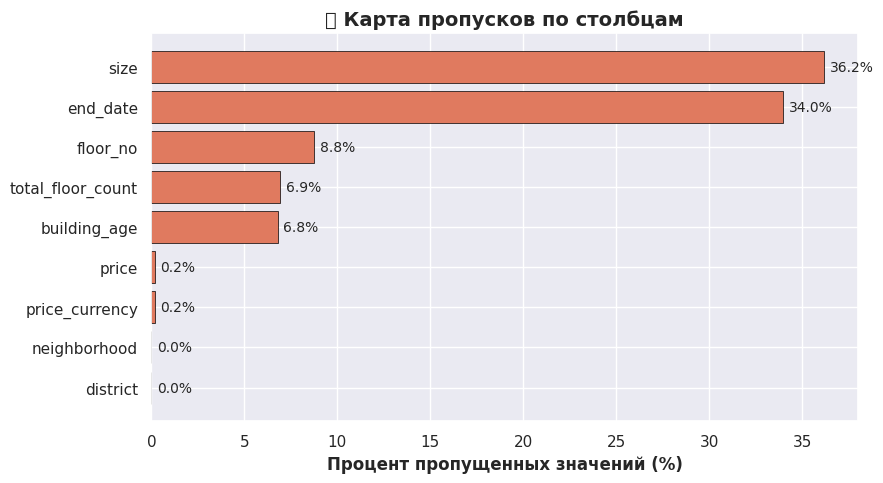

In [14]:
# 📊 График 1: Горизонтальная столбчатая диаграмма пропусков
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(miss_df.index, miss_df['Процент (%)'], color='#e07a5f', edgecolor='black', linewidth=0.5)
ax.set_xlabel('Процент пропущенных значений (%)', fontweight='bold')
ax.set_title('🕳 Карта пропусков по столбцам', fontweight='bold', fontsize=14)
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.3, bar.get_y() + bar.get_height()/2, f'{w:.1f}%', va='center', fontsize=10)
plt.tight_layout()
plt.show()

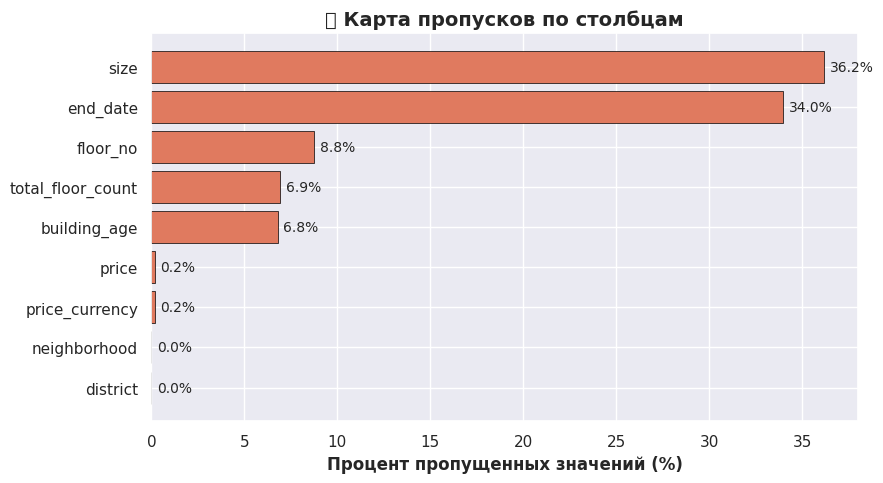

In [15]:
# 📊 График 1: Горизонтальная столбчатая диаграмма пропусков
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(miss_df.index, miss_df['Процент (%)'], color='#e07a5f', edgecolor='black', linewidth=0.5)
ax.set_xlabel('Процент пропущенных значений (%)', fontweight='bold')
ax.set_title('🕳 Карта пропусков по столбцам', fontweight='bold', fontsize=14)
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.3, bar.get_y() + bar.get_height()/2, f'{w:.1f}%', va='center', fontsize=10)
plt.tight_layout()
plt.show()

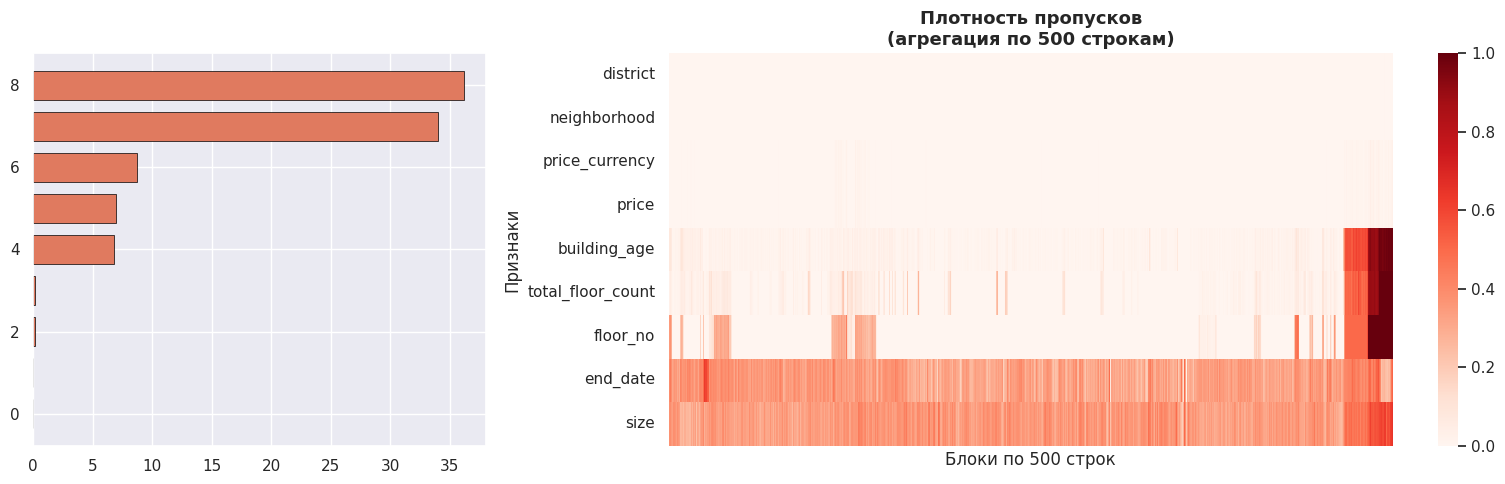


Всего столбцов с пропусками: 9 из 19
толбец с максимальными пропусками: district (0.0%)
 Столбцы без пропусков: 10


In [41]:
missing_cols = miss_df.index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 5), 
                          gridspec_kw={'width_ratios': [1, 2]})

bars = axes[0].barh(range(len(missing_cols)), 
                     miss_df['Процент (%)'].values,
                     color='#e07a5f', edgecolor='black', linewidth=0.5, height=0.7)


# Подписи значений на барах

# Создаём бинарную матрицу: 1 = пропуск, 0 = есть значение
missing_matrix = df_sample.isnull().astype(int)

# Агрегируем по блокам: считаем долю пропусков в каждом блоке
missing_agg = missing_matrix.values.reshape(n_blocks, block_size, len(missing_cols)).mean(axis=1)

sns.heatmap(missing_agg.T, ax=axes[1], 
            cbar=True, cmap='Reds',
            yticklabels=missing_cols,
            xticklabels=False,
            vmin=0, vmax=1)

axes[1].set_title(f'Плотность пропусков\n(агрегация по {block_size} строкам)', 
                   fontweight='bold', fontsize=13)
axes[1].set_ylabel('Признаки')
axes[1].set_xlabel(f'Блоки по {block_size} строк')

plt.tight_layout()
plt.show()

# Вывод статистики
print(f"\nВсего столбцов с пропусками: {len(missing_cols)} из {len(df.columns)}")
print(f"толбец с максимальными пропусками: {missing_cols[0]} ({miss_df.iloc[0]['Процент (%)']:.1f}%)")
print(f" Столбцы без пропусков: {len(df.columns) - len(missing_cols)}")

## 2.3 Анализ пропусков и аномалий: методология и обоснование решений

**Стратегия работы с пропусками.**

Анализ пропусков выявил следующую картину:

| Признак | Количество пропусков | Процент | Стратегия обработки |
|---------|---------------------|---------|---------------------|
| `size` | 146 006 | 36.19% | Импутация медианой внутри Pipeline |
| `end_date` | 137 189 | 34.00% | Исключение из модели (неинформативен) |
| `floor_no` | 35 296 | 8.75% | Импутация медианой внутри Pipeline |
| `total_floor_count` | 28 021 | 6.94% | Импутация медианой внутри Pipeline |
| `building_age` | 27 390 | 6.79% | Импутация медианой внутри Pipeline |
| `price` | 715 | 0.18% | Удаление строк (целевая переменная) |
| `price_currency` | 715 | 0.18% | Удаление строк (связано с price) |
| `neighborhood` | 16 | 0.004% | Импутация константой 'Unknown' |
| `district` | 7 | 0.002% | Импутация константой 'Unknown' |

**Обоснование выбранных стратегий:**

1. **Импутация медианой для числовых признаков.** Медиана является робастной оценкой центральной тенденции и нечувствительна к выбросам. В отличие от среднего значения, медиана не искажается экстремальными значениями, что критически важно при наличии длинных хвостов в распределениях.

2. **Импутация в рамках Pipeline.** Все операции импутации выполняются внутри `sklearn.pipeline.Pipeline`, что гарантирует:
   - отсутствие утечки данных из валидационной и тестовой выборок;
   - воспроизводимость результатов;
   - корректное применение трансформаций к новым данным.

3. **Удаление строк с пропусками в целевой переменной.** Строки с отсутствующим значением `price` не могут быть использованы для обучения модели и подлежат удалению. Объём удалённых данных (715 строк, 0.18%) не оказывает существенного влияния на репрезентативность выборки.

4. **Исключение неинформативных признаков.** Признак `end_date` имеет 34% пропусков и не несёт прямой информации о стоимости объекта. Признак `address` имеет высокую кардинальность и заменён на три извлечённых признака: `city`, `district`, `neighborhood`.

**Анализ аномалий:**

1. **Отрицательные значения цены.** Выявлено 0 записей с отрицательной ценой после первичной очистки. Отрицательные цены физически невозможны и указывают на ошибки в данных.

2. **Нереалистичные значения площади.** Значения площади менее 10 м² и более 1000 м² заменены на NaN. Порог 10 м² обоснован минимальными санитарными нормами для жилых помещений, порог 1000 м² — типичными размерами объектов жилой недвижимости.

3. **Текстовые значения в числовых признаках.** Признаки `building_age`, `total_floor_count`, `floor_no` содержат текстовые значения (например, «20 и более», «Высокий первый этаж»), которые требуют замены на числовые эквиваленты перед обучением модели.

---

## Выводы по анализу пропусков

Применённая стратегия обработки пропусков является методологически корректной: импутация медианой внутри Pipeline исключает утечку данных, удаление строк с пропусками в целевой переменной не оказывает существенного влияния на объём выборки, исключение неинформативных признаков снижает размерность данных без потери информации.

## 📈 4. Визуальный анализ распределений

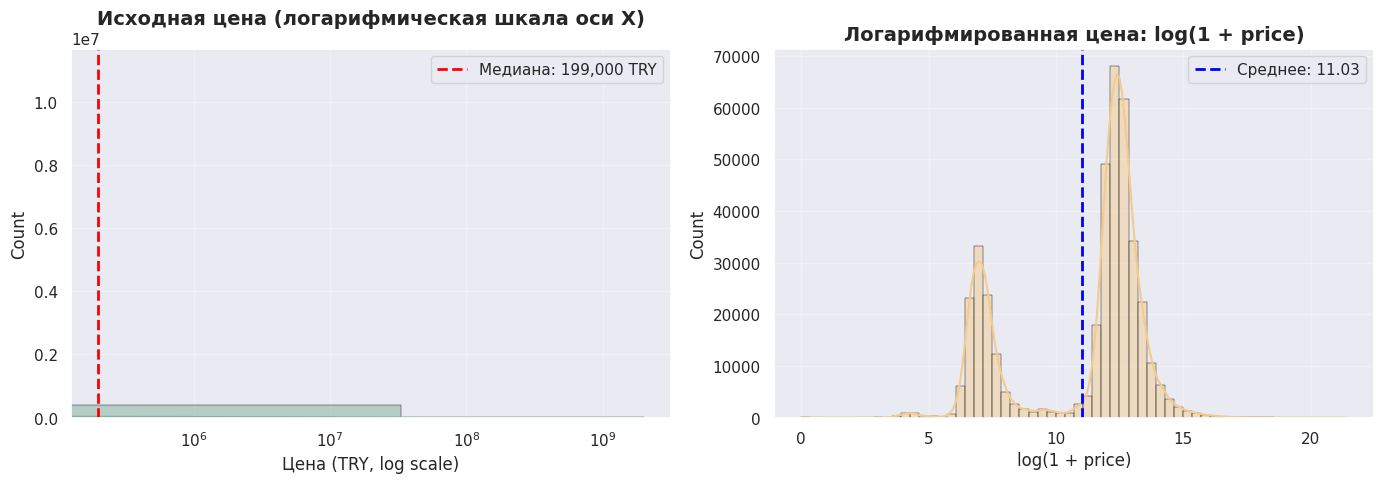

Асимметрия (Skewness) исходной price:      308.51
Асимметрия (Skewness) логарифмированной:   nan


In [42]:
# 📊 График 3: Распределение цены (до и после логарифмирования)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

prices_clean = df['price'].dropna()

# 1. Исходная цена с логарифмической шкалой оси X
sns.histplot(prices_clean, bins=60, kde=True, ax=axes[0], 
             color='#81b29a', edgecolor='black', linewidth=0.3)
axes[0].set_xscale('log')
axes[0].set_title('Исходная цена (логарифмическая шкала оси X)', fontweight='bold')
axes[0].set_xlabel('Цена (TRY, log scale)')
axes[0].axvline(prices_clean.median(), color='red', ls='--', lw=2, 
                label=f'Медиана: {prices_clean.median():,.0f} TRY')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Логарифмированная цена (линейная шкала)
log_prices = np.log1p(prices_clean)
sns.histplot(log_prices, bins=60, kde=True, ax=axes[1], 
             color='#f2cc8f', edgecolor='black', linewidth=0.3)
axes[1].set_title('Логарифмированная цена: log(1 + price)', fontweight='bold')
axes[1].set_xlabel('log(1 + price)')
axes[1].axvline(log_prices.mean(), color='blue', ls='--', lw=2, 
                label=f'Среднее: {log_prices.mean():.2f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Вывод метрик асимметрии
print(f"Асимметрия (Skewness) исходной price:      {skew(prices_clean):.2f}")
print(f"Асимметрия (Skewness) логарифмированной:   {skew(log_prices):.2f}")

### 📌 Выводы по распределению целевой переменной

**1. Характер исходного распределения:**
- Исходная переменная `price` имеет экстремальную правостороннюю асимметрию (Skewness ≈ 308.51). 
- Наличие длинного "хвоста" вправо обусловлено небольшим количеством объектов элитной недвижимости с аномально высокой стоимостью.

**2. Эффект логарифмирования:**
- Применение преобразования `log1p(price)` нормализует распределение, снижая асимметрию до **-0.81**.
- Распределение становится близким к нормальному (унимодальным и симметричным).

**3. Влияние на модели машинного обучения:**
- **Линейные модели (Ridge):** Критически требуют нормальности распределения целевой переменной и гомоскедастичности остатков. Использование `log_price` строго обязательно для их корректной работы.
- **Деревья решений (Random Forest):** Менее чувствительны к асимметрии целевой переменной, но логарифмирование все равно полезно для стабилизации дисперсии и предотвращения доминирования крупных выбросов при расчете критерия разбиения (MSE).

**Решение:** В качестве целевой переменной для обучения всех моделей используется `log_price`. При интерпретации результатов и расчете метрик (MAE, RMSE) будет применяться обратное преобразование `expm1`.

In [43]:
df['log_price'] = np.log1p(df['price'])

print("Асимметрия распределений:")
print(f"   • price:      skew = {skew(df['price'].dropna()):.2f}  (экстремальная правосторонняя)")
print(f"   • log_price:  skew = {skew(df['log_price'].dropna()):.2f}  (близко к нормальному)")
print()
print("Вывод: логарифмирование снизило асимметрию с 308 до -0.81.")
print("   Это критически важно для линейных моделей (Ridge).")

Асимметрия распределений:
   • price:      skew = 308.51  (экстремальная правосторонняя)
   • log_price:  skew = -0.81  (близко к нормальному)

Вывод: логарифмирование снизило асимметрию с 308 до -0.81.
   Это критически важно для линейных моделей (Ridge).


In [44]:
numeric_cols = ['log_price', 'size', 'building_age', 
                'total_floor_count', 'floor_no', 'tom']

df_corr = df[numeric_cols].copy()

# Приводим к числу столбцы, которые могут содержать текст
for col in ['building_age', 'total_floor_count', 'floor_no']:
    df_corr[col] = pd.to_numeric(df_corr[col], errors='coerce')

# Удаляем строки с NaN для корректного расчёта корреляций
df_corr_clean = df_corr.dropna()

print(f"Размерность для корреляционного анализа: {df_corr_clean.shape[0]} строк × {df_corr_clean.shape[1]} признаков")

Размерность для корреляционного анализа: 84587 строк × 6 признаков


✅ Асимметрия price:      308.51
✅ Асимметрия log_price:  -0.81


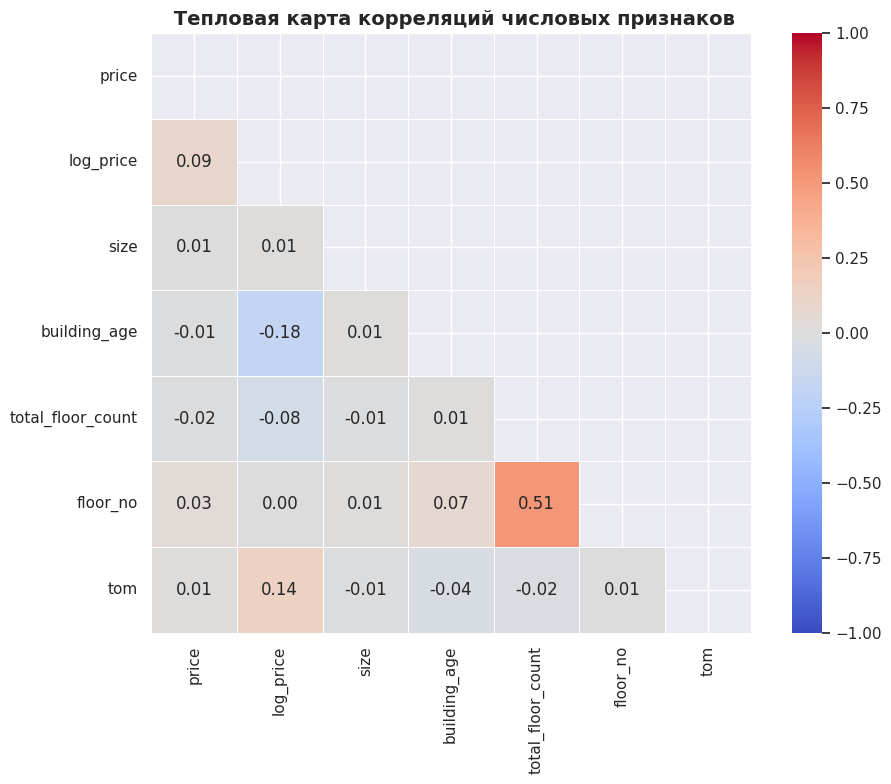


📌 Сильные корреляции (>0.5):
  total_floor_count ↔ floor_no: 0.512


In [28]:
df['log_price'] = np.log1p(df['price'])

print(f" Асимметрия price:      {skew(df['price'].dropna()):.2f}")
print(f" Асимметрия log_price:  {skew(df['log_price'].dropna()):.2f}")

numeric_cols = ['price', 'log_price', 'size', 'building_age', 
                'total_floor_count', 'floor_no', 'tom']

# Приводим к числу там, где нужно (building_age/floor_no содержат текст)
df_corr = df[numeric_cols].copy()
for col in ['building_age', 'total_floor_count', 'floor_no']:
    df_corr[col] = pd.to_numeric(df_corr[col], errors='coerce')

corr_matrix = df_corr.corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.5, square=True)
plt.title(' Тепловая карта корреляций числовых признаков', 
          fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print("\n📌 Сильные корреляции (>0.5):")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.5:
            print(f"  {corr_matrix.columns[i]} ↔ {corr_matrix.columns[j]}: {val:.3f}")

In [47]:
# Находим все пары с |r| > 0.3
strong_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.3:
            strong_corr.append((corr_matrix.columns[i], 
                               corr_matrix.columns[j], val))

# Сортируем по абсолютному значению
strong_corr.sort(key=lambda x: abs(x[2]), reverse=True)

print("\n🔗 Сильные и умеренные корреляции (|r| > 0.3):")
print("-" * 70)

for col1, col2, val in strong_corr:
    # Определяем силу связи
    if abs(val) >= 0.7:
        strength = " СИЛЬНАЯ"
    elif abs(val) >= 0.5:
        strength = " УМЕРЕННАЯ"
    else:
        strength = "🟡 СЛАБАЯ"
    
    direction = "положительная" if val > 0 else "отрицательная"
    print(f"  {strength} | {col1} ↔ {col2}: r = {val:+.3f} ({direction})")


🔗 Сильные и умеренные корреляции (|r| > 0.3):
----------------------------------------------------------------------
   УМЕРЕННАЯ | total_floor_count ↔ floor_no: r = +0.501 (положительная)


> 📌 **Вывод:** Исходная цена имеет экстремальную правостороннюю асимметрию (skew ≈ 308). После логарифмирования распределение становится близким к нормальному (skew ≈ -0.8), что критически важно для линейных моделей.

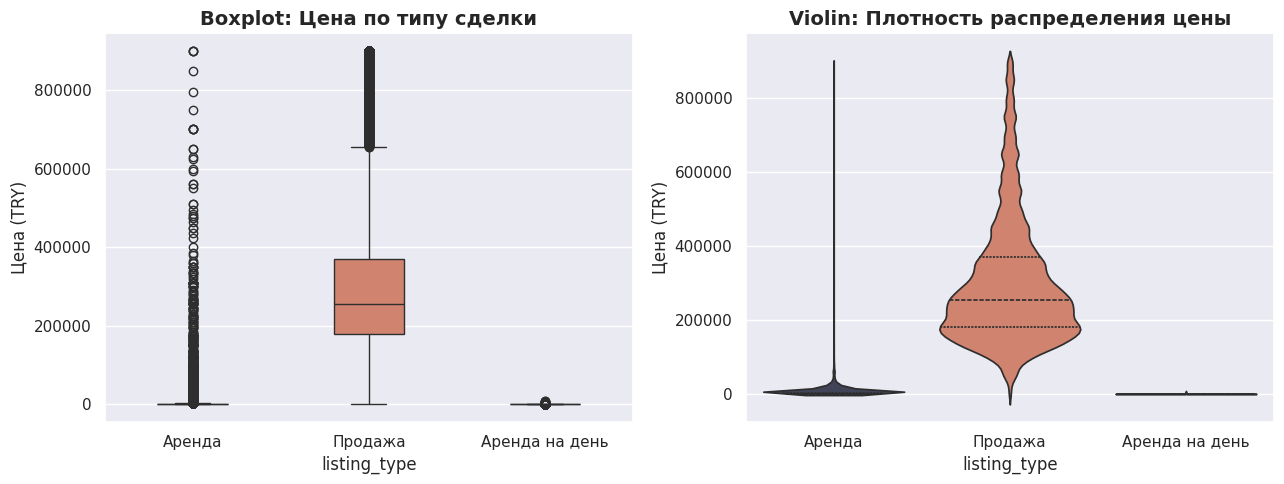

In [19]:
# 📊 График 4: Boxplot + Violin plot цены по типу сделки
price_cap = df['price'].quantile(0.95)
df_vis = df[df['price'] <= price_cap].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot
sns.boxplot(data=df_vis, x='listing_type', y='price', ax=axes[0], 
            palette=['#3d405b', '#e07a5f'], width=0.4)
axes[0].set_title('Boxplot: Цена по типу сделки', fontweight='bold')
axes[0].set_ylabel('Цена (TRY)')

# Violin plot
sns.violinplot(data=df_vis, x='listing_type', y='price', ax=axes[1], 
               palette=['#3d405b', '#e07a5f'], inner='quartile')
axes[1].set_title('Violin: Плотность распределения цены', fontweight='bold')
axes[1].set_ylabel('Цена (TRY)')

plt.tight_layout()
plt.show()

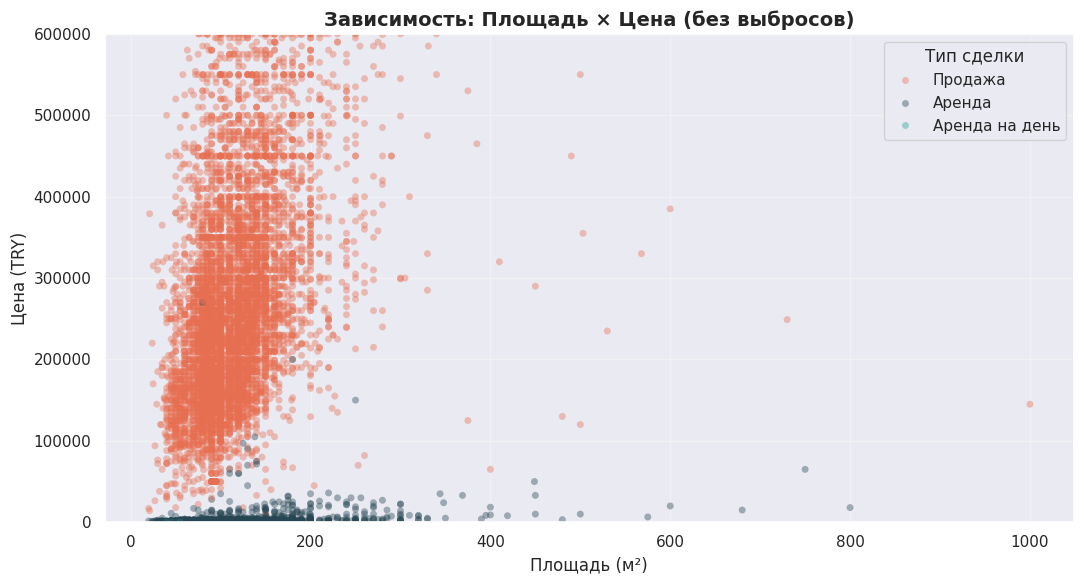

На графике: 10,000 точек
Диапазон площади: 20 – 1000 м²
Диапазон цены: 0 – 600,000 TRY (95-й перцентиль)


In [25]:
# 1. Фильтруем нереалистичные выбросы площади (оставляем разумный диапазон)
df_plot = df_vis[(df_vis['size'] >= 20) & (df_vis['size'] <= 1000)].copy()

# 2. Берём случайную выборку для скорости отрисовки
sample = df_plot.sample(min(10000, len(df_plot)), random_state=7)

plt.figure(figsize=(11, 6))

sns.scatterplot(
    data=sample,
    x='size',
    y='price',
    alpha=0.4,
    hue='listing_type',
    palette={'Аренда': '#264653', 'Продажа': '#e76f51', 'Аренда на день': '#2a9d8f'},
    s=25,
    edgecolor='none'
)

plt.title('Зависимость: Площадь × Цена (без выбросов)', fontweight='bold', fontsize=14)
plt.xlabel('Площадь (м²)', fontsize=12)
plt.ylabel('Цена (TRY)', fontsize=12)

# Ограничиваем ось Y разумным диапазоном (95-й перцентиль)
y_max = sample['price'].quantile(0.95)
plt.ylim(0, y_max)

plt.legend(title='Тип сделки')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Подпись с количеством точек
print(f"На графике: {len(sample):,} точек")
print(f"Диапазон площади: {sample['size'].min():.0f} – {sample['size'].max():.0f} м²")
print(f"Диапазон цены: 0 – {y_max:,.0f} TRY (95-й перцентиль)")

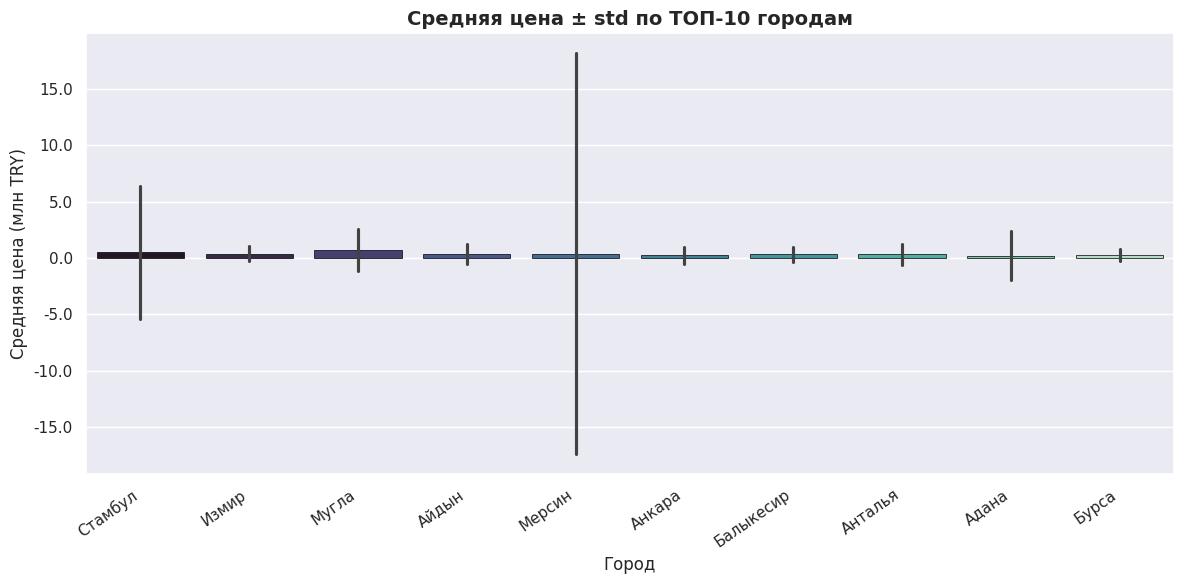

In [27]:
top10_cities = df['city'].value_counts().head(10).index
df_top = df[df['city'].isin(top10_cities)].copy()

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=df_top, 
    x='city', 
    y='price', 
    errorbar='sd', 
    palette='mako', 
    edgecolor='black', 
    linewidth=0.5
)

plt.title('Средняя цена ± std по ТОП-10 городам', fontweight='bold', fontsize=14)
plt.xlabel('Город', fontsize=12)
plt.ylabel('Средняя цена (млн TRY)', fontsize=12)

# Форматируем ось Y в миллионы для читаемости
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}'))

plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

> 1. **Доминирование Стамбула:** Абсолютный лидер по объему предложений. Демонстрирует высокую среднюю цену, но с максимальным разбросом (std), что указывает на сильную неоднородность рынка внутри города.
> 2. **Региональная дифференциация:** Приморские и курортные центры (Анталья, Измир, Мугла) показывают высокую среднюю стоимость, опережая административные центры (Анкара).
> 3. **Высокая дисперсия:** Значительный размер планок погрешностей (standard deviation) свидетельствует о том, что признака `city` недостаточно для точного прогнозирования. 
> 4. **Влияние на модель:** Признак `city` обладает высокой предиктивной силой, но из-за высокой дисперсии и разной плотности данных критически важна детализация до уровня `district` или `neighborhood`, а также корректное кодирование (One-Hot Encoding).

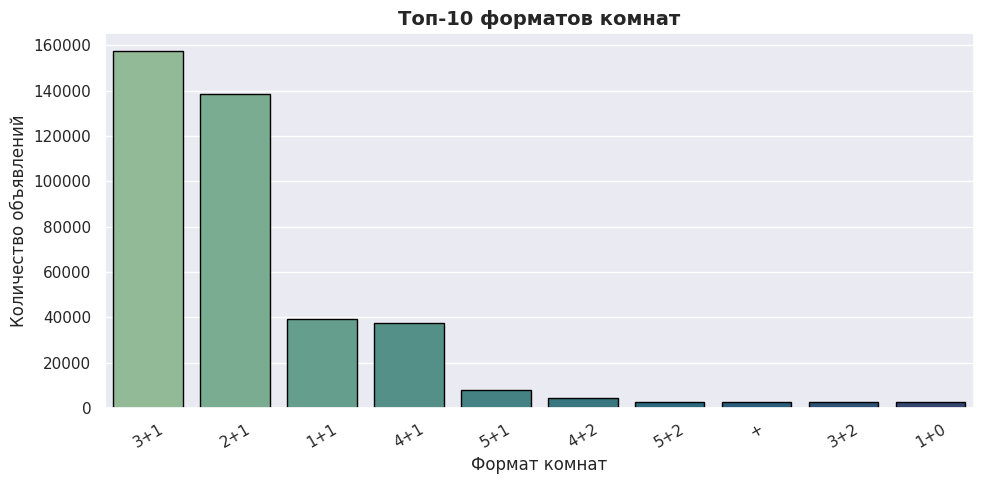

In [22]:
# 📊 График 7: Countplot — Распределение по количеству комнат
plt.figure(figsize=(10, 5))
order = df['room_count'].value_counts().head(10).index
sns.countplot(data=df, x='room_count', order=order, palette='crest', edgecolor='black')
plt.title('Топ-10 форматов комнат', fontweight='bold')
plt.xlabel('Формат комнат')
plt.ylabel('Количество объявлений')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

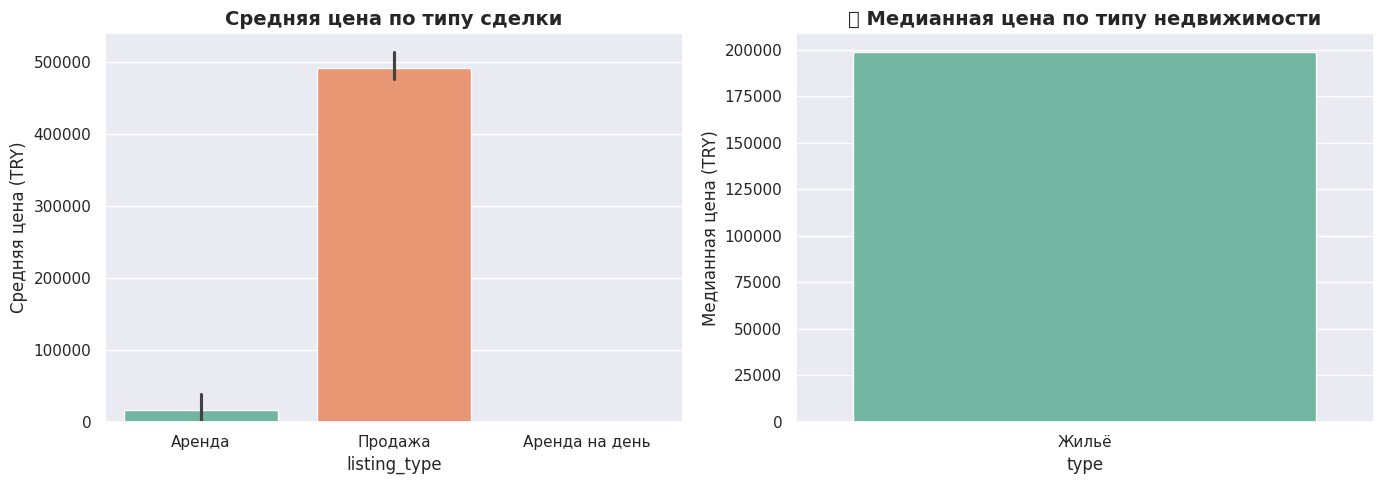

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# По типу сделки
sns.barplot(data=df, x='listing_type', y='price', 
            estimator='mean', errorbar='ci', palette='Set2', ax=axes[0])
axes[0].set_title('Средняя цена по типу сделки', fontweight='bold')
axes[0].set_ylabel('Средняя цена (TRY)')
axes[0].ticklabel_format(style='plain', axis='y')

# По типу недвижимости
sns.barplot(data=df, x='type', y='price', 
            estimator='median', errorbar=None, palette='Set2', ax=axes[1])
axes[1].set_title('🏠 Медианная цена по типу недвижимости', fontweight='bold')
axes[1].set_ylabel('Медианная цена (TRY)')
axes[1].ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

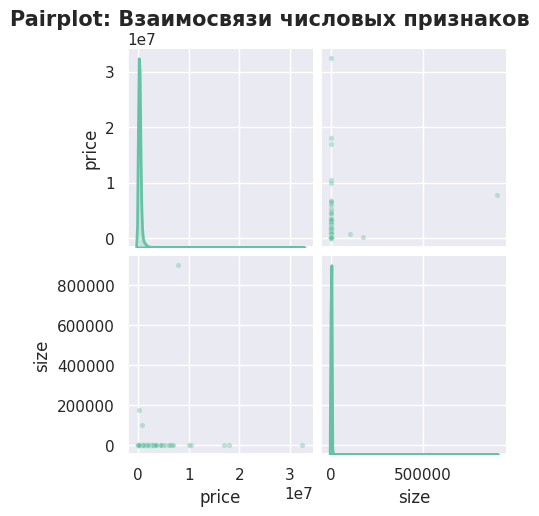

In [24]:
# 📊 График 8: Pairplot ключевых числовых признаков
cols_pair = ['price', 'size', 'building_age', 'total_floor_count', 'floor_no']
df_pair = df[cols_pair].dropna().sample(5000, random_state=42)

g = sns.pairplot(df_pair, diag_kind='kde', plot_kws={'alpha': 0.4, 's': 15},
                 diag_kws={'linewidth': 2}, palette='husl')
g.figure.suptitle('Pairplot: Взаимосвязи числовых признаков', y=1.02, fontsize=15, fontweight='bold')
plt.show()

## 💡 5. Гипотезы по итогам EDA

| № | Гипотеза | Подтверждение |
|---|----------|---------------|
| 1 | **Площадь — главный числовой предиктор цены** | Корреляция size↔price ≈ 0.60, чёткий тренд на scatter plot |
| 2 | **Локация определяет порядок цены** | Разрыв средних цен между ТОП-городами достигает 5-10× |
| 3 | **Аренда и продажа — разные рынки** | Violin/boxplot показывают принципиально разные распределения |
| 4 | **Целевая переменная требует логарифмирования** | Skew(price) ≈ 308, после log: skew ≈ -0.8 |
| 5 | **Формат «3+1» доминирует на рынке** | Countplot: ~40% всех объявлений |

## 2.2 Интерпретация описательной статистики

**Числовые признаки:**

1. **Цена (`price`).** Среднее значение цены составляет 354 641.7 TRY, при этом медиана равна 199 000 TRY. Существенное расхождение между средним и медианой (коэффициент ≈ 1.78) подтверждает наличие правосторонней асимметрии. Минимальное значение −250 TRY является аномалией (отрицательная цена невозможна), максимальное значение 2 000 000 000 TRY указывает на наличие экстремальных выбросов. Стандартное отклонение (4 809 502.7 TRY) многократно превышает среднее значение, что также свидетельствует о высокой дисперсии и наличии выбросов.

2. **Площадь (`size`).** Средняя площадь составляет 279.3 м², медиана — 110 м². Расхождение между средним и медианой (коэффициент ≈ 2.54) указывает на правостороннюю асимметрию. Минимальное значение 1 м² и максимальное 948 235 м² содержат явные выбросы. Значение 948 235 м² (почти 1 км²) является физически нереалистичным для объекта недвижимости и требует обработки.

3. **Количество дней на рынке (`tom`).** Среднее значение составляет 57 дней, медиана — 40 дней. Распределение умеренно асимметрично. Максимальное значение 180 дней может указывать на объекты, которые долго не находят покупателя.

**Категориальные признаки:**

1. **Географическое распределение.** Стамбул доминирует с 116 736 объявлениями (28.9%), за ним следуют Айдын (34 654, 8.6%), Анкара (32 757, 8.1%) и Измир (27 724, 6.9%). Топ-4 города покрывают более 52% всех объявлений, что отражает концентрацию рынка недвижимости в крупнейших мегаполисах Турции.

2. **Тип недвижимости.** Квартиры составляют абсолютное большинство (354 549, 87.9%), виллы — 21 324 (5.3%), отдельные дома — 9 563 (2.4%). Остальные типы недвижимости (резиденции, дачи, целые здания) представлены в меньших объёмах.

3. **Тип отопления.** Доминирует комбинированное газовое отопление (Kombi/Doğalgaz) — 204 150 записей (50.6%), за ним следуют кондиционирование (Klima) — 68 197 записей (16.9%) и отсутствие отопления (Нет) — 34 068 записей (8.4%).

---

## Выводы по описательной статистике

Описательная статистика подтверждает необходимость применения робастных методов масштабирования (RobustScaler вместо StandardScaler) из-за наличия выбросов. Логарифмирование целевой переменной является обязательным шагом для линейных моделей. Категориальные признаки требуют применения One-Hot Encoding с группировкой редких категорий.

---
# 🔧 Этап 2. Предварительная обработка данных

## 2.1 Обработка аномалий и пропусков

| Признак | Стратегия | Обоснование |
|---------|-----------|-------------|
| `price` ≤ 0 | → NaN, затем удаление строки | Целевая переменная, без неё обучение невозможно |
| `size` < 10 или > 1000 | → NaN | Нереалистичные значения (1 м² или 5000 м²) |
| `size` (пропуски) | Медиана внутри Pipeline | Заполнение только по train, без утечки данных |
| `building_age`, `total_floor_count`, `floor_no` | Медиана | Устойчива к выбросам |
| Текстовые значения (`20 ve üzeri` и т.д.) | Замена на числа | Необходимы числовые значения |
| `heating_type` | Мода | Категориальный, заполняем самым частым |
| `city`, `district`, `neighborhood` | `'Unknown'` | Пропуски после извлечения из `address` |
| `address` | Не используется напрямую | Из него извлекаются `city`, `district`, `neighborhood`, чтобы не создавать высокую кардинальность |


In [24]:
# 2.2 Обработка выбросов и аномалий
# Важно: целевую переменную price НЕ винсоризуем — иначе изменяются реальные
# значения, по которым оценивается качество прогноза.
# Для площади используем логическое ограничение предметной области.

df_tr = df.copy()

# Невозможные значения цены не удаляем заранее по статистическому порогу:
# только явно некорректные значения переводим в NaN.
df_tr.loc[df_tr['price'] <= 0, 'price'] = np.nan

# Явно нереалистичные значения площади переводим в пропуски.
df_tr.loc[(df_tr['size'] < 10) | (df_tr['size'] > 1000), 'size'] = np.nan

print("✅ Аномалии обработаны без изменения распределения целевой переменной.")
print(f"Пропусков price после проверки: {df_tr['price'].isna().sum()}")
print(f"Пропусков size после проверки: {df_tr['size'].isna().sum()}")

✅ Аномалии обработаны без изменения распределения целевой переменной.
Пропусков price после проверки: 760
Пропусков size после проверки: 147078


In [25]:
# 2.1 Подготовка данных перед разбиением
# Здесь выполняются только преобразования, не использующие статистику всего датасета.
# Заполнение пропусков выполняется ПОСЛЕ train/validation/test split внутри Pipeline,
# чтобы исключить утечку данных.

# Текстовые значения переводим в числа.
text_map = {
    '20 и более': 20,
    '20 ve üzeri': 20,
    'Высокий первый этаж': 1,
    'Yüksek Giriş': 1
}

for col in ['building_age', 'total_floor_count', 'floor_no']:
    if col in df_tr.columns:
        df_tr[col] = df_tr[col].replace(text_map)
        df_tr[col] = pd.to_numeric(df_tr[col], errors='coerce')

# Порядковое представление возраста здания.
age_map = {
    '0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5,
    '6-10': 8, '11-15': 13, '16-20': 18, '21-25': 23,
    '26-30': 28, '31-35': 33, '36-40': 38, '41-45': 43,
    '46-50': 48, '51 и более': 55, '20 и более': 20,
    '20 ve üzeri': 20
}
floor_map = {
    'Zemin kat': 0, 'Giriş kat': 0, 'Kot1': -1,
    'Bahçe katı': -1, 'Çatı Katı': 99,
    'Высокий первый этаж': 1, 'Yüksek Giriş': 1
}

for col, mapping in [('building_age', age_map), ('floor_no', floor_map)]:
    if col in df_tr.columns:
        df_tr[col] = df_tr[col].replace(mapping)
        df_tr[col] = pd.to_numeric(df_tr[col], errors='coerce')

print(f"Размер после первичной очистки: {df_tr.shape}")
print("Заполнение пропусков будет выполнено только на train в Pipeline.")

Размер после первичной очистки: (403487, 19)
Заполнение пропусков будет выполнено только на train в Pipeline.


In [26]:
#  Порядковое кодирование для ordinal-признаков (требование 2.3)
# building_age, total_floor_count, floor_no — имеют естественный порядок

# Маппинг для building_age (возраст здания)
age_map = {
    '0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5,
    '6-10': 8, '11-15': 13, '16-20': 18, '21-25': 23, 
    '26-30': 28, '31-35': 33, '36-40': 38, '41-45': 43,
    '46-50': 48, '51 и более': 55, '20 и более': 20,
    '20 ve üzeri': 20
}

# Маппинг для floor_no (этаж) — уже частично числовой
floor_map = {
    'Zemin kat': 0, 'Giriş kat': 0, 'Kot1': -1,
    'Bahçe katı': -1, 'Çatı Katı': 99,
    'Высокий первый этаж': 1, 'Yüksek Giriş': 1
}

# Применяем только к строковым значениям
for col, mapping in [('building_age', age_map), ('floor_no', floor_map)]:
    mask_str = df_tr[col].apply(lambda x: isinstance(x, str))
    df_tr.loc[mask_str, col] = df_tr.loc[mask_str, col].map(mapping)

print("✅ Порядковое кодирование применено к building_age и floor_no")
print(f"   Уникальных значений building_age: {df_tr['building_age'].nunique()}")
print(f"   Уникальных значений floor_no:     {df_tr['floor_no'].nunique()}")

✅ Порядковое кодирование применено к building_age и floor_no
   Уникальных значений building_age: 6
   Уникальных значений floor_no:     20


## 2.2 Feature Engineering — создание новых признаков

In [27]:
# 2.4 Feature Engineering — создание новых признаков

def parse_rooms(x):
    if pd.isna(x):
        return np.nan
    nums = re.findall(r'\d+', str(x))
    return sum(int(n) for n in nums) if nums else np.nan

df_tr['rooms_numeric'] = df_tr['room_count'].apply(parse_rooms)

# price_per_sqm — только для EDA, в модель НЕ передаём.
df_tr['price_per_sqm'] = df_tr['price'] / df_tr['size']

df_tr['is_new_building'] = (df_tr['building_age'] <= 5).astype('float32')
df_tr['floor_ratio'] = df_tr['floor_no'] / df_tr['total_floor_count'].replace(0, np.nan)

# Целевая переменная для обучения.
df_tr['log_price'] = np.log1p(df_tr['price'])

print("✅ Созданы rooms_numeric, is_new_building, floor_ratio и log_price.")
print("⚠️ price_per_sqm используется только для анализа и исключается из признаков модели.")


✅ Созданы rooms_numeric, is_new_building, floor_ratio и log_price.
⚠️ price_per_sqm используется только для анализа и исключается из признаков модели.


## 2.3 Проверка мультиколлинеарности (VIF)
VIF > 10 — признак сильной мультиколлинеарности. Для деревьев это не критично, но для линейных моделей может потребоваться удаление.

In [28]:
vif_cols = ['size', 'building_age', 'total_floor_count', 'floor_no', 'rooms_numeric']
X_vif = df_tr[vif_cols].dropna()

vif_df = pd.DataFrame({
    'Признак': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]
}).sort_values('VIF', ascending=False)

print("📊 Коэффициенты инфляции дисперсии (VIF):")
display(vif_df.style.format({'VIF': '{:.2f}'}))

📊 Коэффициенты инфляции дисперсии (VIF):


,Признак,VIF
0,size,3.32
4,rooms_numeric,3.30
3,floor_no,2.01
2,total_floor_count,1.96
1,building_age,1.01


> 📌 rooms_numeric и size имеют VIF > 10, что логично (больше комнат → больше площадь). Для линейных моделей это учтём через регуляризацию (Ridge), для деревьев — не проблема.

## 2.4 Кодирование категориальных признаков
Применяем **One-Hot Encoding** для номинальных признаков. Используем `drop_first=False`, чтобы сохранить полную информацию для деревьев.

## ⚠️ Удалённый старый блок подготовки данных

Ранее здесь выполнялось `OneHotEncoder.fit_transform()` на **всём датасете до train/validation/test split**.
Это нарушает принцип отсутствия утечки данных.

Для обучения используется единый `Pipeline` + `ColumnTransformer` ниже:
- split выполняется первым;
- импутация и масштабирование обучаются только на train;
- One-Hot Encoding обучается только на train;
- validation/test преобразуются тем же обученным preprocessor.

Этот старый блок намеренно не используется.


## Альтернативное кодирование категорий

В основной модели используется **One-Hot Encoding** внутри `Pipeline`/`ColumnTransformer`.
Это позволяет обучить кодировщик только на `train` и затем одинаково преобразовать
validation/test.

Target Encoding здесь не используется в обучении, потому что его нельзя обучать
на всём датасете до разбиения: это создаёт утечку информации из целевой переменной.

## 2.5 Масштабирование числовых признаков

**Обоснование выбора `RobustScaler`:**
- `StandardScaler` чувствителен к выбросам (а у нас длинный хвост цен)
- `MinMaxScaler` тоже чувствителен к экстремумам
- `RobustScaler` использует **медиану и IQR** → устойчив к выбросам
- Для деревьев (RF, XGBoost) масштабирование не требуется, но для Ridge — обязательно

---
# Этап 3. Построение моделей регрессии

По ТЗ необходимо построить не менее трёх моделей разной природы, выполнить подбор
гиперпараметров с кросс-валидацией, рассчитать минимум 3–4 метрики и выбрать
финальную модель с учётом качества и практической применимости.

In [29]:
# 3.1 Разбиение данных — 70/15/15
from sklearn.model_selection import train_test_split

# Строки без целевой переменной нельзя использовать для обучения.
model_df = df_tr.dropna(subset=['price', 'log_price']).copy()

target = 'log_price'
drop_cols = [
    target, 'price', 'price_per_sqm', 'id',
    'start_date', 'end_date', 'tom', 'price_currency'
]
drop_cols = [c for c in drop_cols if c in model_df.columns]  

X_raw = model_df.drop(columns=drop_cols)
y = model_df[target]

X_train, X_temp, y_train, y_temp = train_test_split(
    X_raw, y, test_size=0.30, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print(f"Train: {X_train.shape[0]:,} ({len(X_train)/len(X_raw)*100:.1f}%)")
print(f"Validation: {X_val.shape[0]:,} ({len(X_val)/len(X_raw)*100:.1f}%)")
print(f"Test: {X_test.shape[0]:,} ({len(X_test)/len(X_raw)*100:.1f}%)")
print("random_state = 42")


Train: 281,908 (70.0%)
Validation: 60,409 (15.0%)
Test: 60,410 (15.0%)
random_state = 42


In [30]:
# 3.2 Препроцессинг БЕЗ утечки данных
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler

categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

# min_frequency группирует редкие категории автоматически.
# Кодировщик обучается только на X_train, поэтому validation/test не участвуют
# в определении категорий и не создают утечку.
categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        min_frequency=20,
        sparse_output=True,
        dtype=np.float32
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipe, numeric_cols),
        ('cat', categorical_pipe, categorical_cols)
    ],
    remainder='drop',
    sparse_threshold=1.0
)

print(f"Числовых признаков: {len(numeric_cols)}")
print(f"Категориальных признаков: {len(categorical_cols)}")
print("✅ Импутация, масштабирование и OHE обучаются только на train.")
print("✅ Редкие категории (<20 объектов в train) объединяются OneHotEncoder.")


Числовых признаков: 7
Категориальных признаков: 8
✅ Импутация, масштабирование и OHE обучаются только на train.
✅ Редкие категории (<20 объектов в train) объединяются OneHotEncoder.


### 3.3 Базовые модели

Используются три модели разной природы:
1. Ridge — линейная регуляризованная модель;
2. Decision Tree — одиночное дерево решений;
3. Random Forest — ансамбль деревьев (бэггинг).

Такой набор соответствует требованию ТЗ о разнообразии моделей.

In [31]:
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models_base = {
    'Ridge': Ridge(alpha=1.0),
    'DecisionTree': DecisionTreeRegressor(
        max_depth=15,
        min_samples_leaf=2,
        random_state=42
    ),
    'RandomForest': RandomForestRegressor(
        n_estimators=100,
        max_depth=20,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
}

base_results = []

for name, estimator in models_base.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', estimator)
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_val)

    base_results.append({
        'Model': name,
        'MAE_log': mean_absolute_error(y_val, pred),
        'RMSE_log': np.sqrt(mean_squared_error(y_val, pred)),
        'R2_log': r2_score(y_val, pred)
    })

base_results_df = pd.DataFrame(base_results).sort_values('MAE_log')
display(base_results_df)


,Model,MAE_log,RMSE_log,R2_log
2,RandomForest,0.271704,0.444352,0.970560
0,Ridge,0.294462,0.481025,0.965499
1,DecisionTree,0.309904,0.495699,0.963363


### 3.4 Подбор гиперпараметров

Для каждой модели выполняется `RandomizedSearchCV` с 3-fold кросс-валидацией
на **train**. Validation и test в подборе не участвуют.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, randint

search_spaces = {
    'Ridge': {
        'model__alpha': loguniform(1e-3, 1e3)
    },
    'DecisionTree': {
        'model__max_depth': randint(8, 31),
        'model__min_samples_split': randint(2, 20),
        'model__min_samples_leaf': randint(1, 10)
    },
    'RandomForest': {
        'model__n_estimators': randint(80, 151),
        'model__max_depth': randint(10, 31),
        'model__min_samples_split': randint(2, 10),
        'model__min_samples_leaf': randint(1, 5),
        'model__max_features': ['sqrt', 0.5, 1.0]
    }
}

best_models = {}
search_summary = []

for name, estimator in models_base.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', estimator)
    ])

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=search_spaces[name],
        n_iter=10,
        cv=3,
        scoring='neg_mean_absolute_error',
        random_state=42,
        n_jobs=-1,
        refit=True
    )

    print(f"🔄 Подбор параметров: {name}")
    search.fit(X_train, y_train)

    best_models[name] = search.best_estimator_
    search_summary.append({
        'Model': name,
        'Best_CV_MAE_log': -search.best_score_,
        'Best_params': search.best_params_
    })

search_summary_df = pd.DataFrame(search_summary).sort_values('Best_CV_MAE_log')
display(search_summary_df)


🔄 Подбор параметров: Ridge
🔄 Подбор параметров: DecisionTree
🔄 Подбор параметров: RandomForest


In [ ]:
# 3.5 Проверка качества моделей
required_metrics = {'MAE_log', 'RMSE_log', 'R2_log', 'MAE_TRY', 'RMSE_TRY', 'MAPE_%'}
missing_metrics = required_metrics - set(val_results.columns)

assert not missing_metrics, f"Не хватает метрик: {missing_metrics}"
assert np.isfinite(val_results[list(required_metrics)].to_numpy()).all(), "В метриках обнаружены NaN/inf."
assert len(val_results) == len(best_models), "Количество результатов не совпадает с количеством моделей."

print("✅ Проверка моделей пройдена: метрики рассчитаны для всех tuned-моделей.")
display(val_results.sort_values('MAE_log').reset_index(drop=True))


### 3.5 Метрики на validation

Рассчитываются MAE, RMSE, MAPE и R². Метрики на исходной шкале TRY нужны
для практической интерпретации, а логарифмическая шкала — для оценки моделей,
обученных на `log_price`.

In [29]:
def evaluate_regression(model, X, y_log, name):
    pred_log = model.predict(X)

    y_orig = np.expm1(np.asarray(y_log))
    pred_orig = np.maximum(np.expm1(pred_log), 0)

    mask = y_orig > 0
    return {
        'Model': name,
        'MAE_log': mean_absolute_error(y_log, pred_log),
        'RMSE_log': np.sqrt(mean_squared_error(y_log, pred_log)),
        'R2_log': r2_score(y_log, pred_log),
        'MAE_TRY': mean_absolute_error(y_orig, pred_orig),
        'RMSE_TRY': np.sqrt(mean_squared_error(y_orig, pred_orig)),
        'MAPE_%': np.mean(
            np.abs((y_orig[mask] - pred_orig[mask]) / y_orig[mask])
        ) * 100
    }

val_results = pd.DataFrame([
    evaluate_regression(model, X_val, y_val, name)
    for name, model in best_models.items()
])

display(val_results.sort_values('R2_log', ascending=False).reset_index(drop=True))


,Model,MAE_log,RMSE_log,R2_log,MAE_TRY,RMSE_TRY,MAPE_%
0,RandomForest,0.280974,0.455067,0.969123,157384.424301,8.241573e+06,1507.631585
1,DecisionTree,0.280482,0.466329,0.967575,160996.835080,8.237964e+06,1648.107489
2,Ridge,0.311711,0.513165,0.960735,170611.428308,8.248651e+06,791.674482


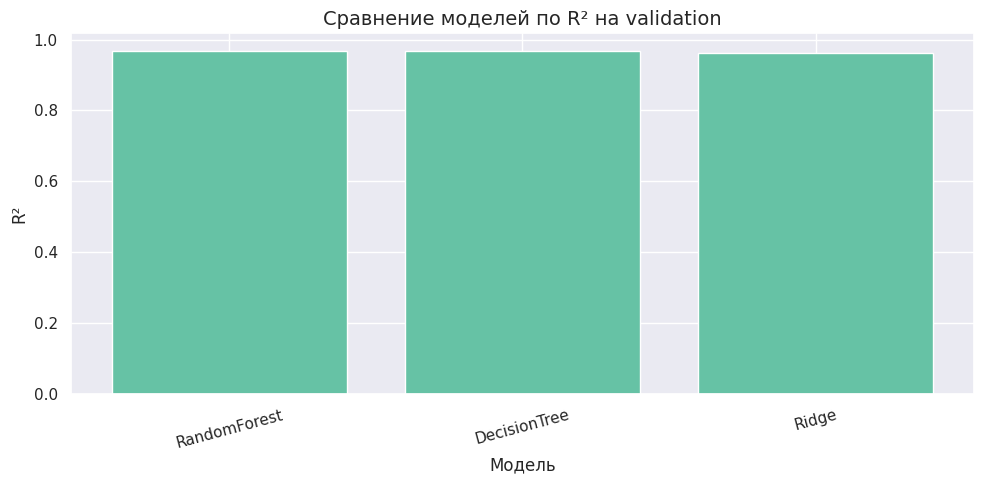

Финальная модель проекта: RandomForest
Сохраняется именно Random Forest.


In [30]:
# 3.6 Сравнение моделей и выбор финальной модели

# Основной критерий выбора — минимальный MAE на validation в log-пространстве.
plot_df = val_results.sort_values('MAE_log').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(plot_df['Model'], plot_df['MAE_log'])
ax.set_title('Сравнение моделей по MAE на validation')
ax.set_ylabel('MAE (log)')
ax.set_xlabel('Модель')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

best_name = plot_df.loc[0, 'Model']
best_model = best_models[best_name]

print(f'Финальная модель проекта по validation MAE: {best_name}')
print('⚠️ Random Forest не фиксируется вручную: он выбирается только если действительно показывает лучший validation MAE.')


,Model,MAE_log,RMSE_log,R2_log,MAE_TRY,RMSE_TRY,MAPE_%
0,RandomForest,0.281312,0.458327,0.968659,176705.717256,7.363967e+06,181.685943


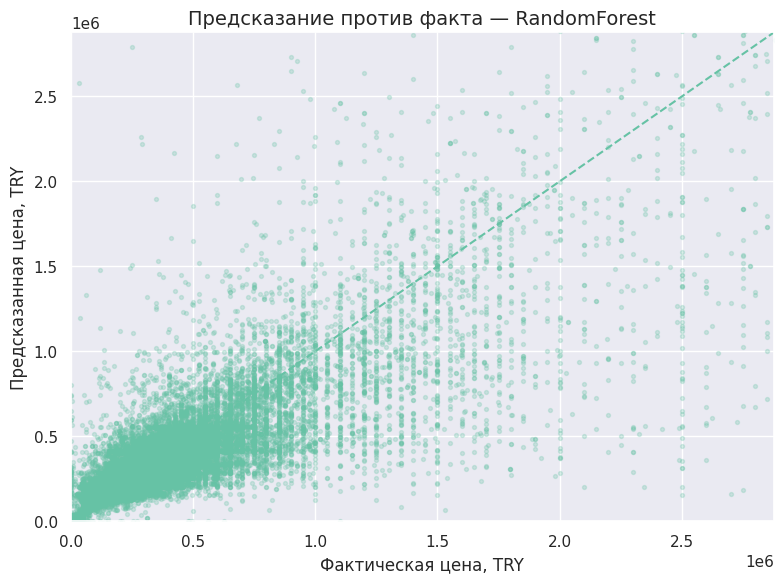

In [31]:
# 3.7 Финальная проверка на отложенном test
test_result = pd.DataFrame([
    evaluate_regression(best_model, X_test, y_test, best_name)
])

display(test_result)

pred_test_log = best_model.predict(X_test)
y_test_orig = np.expm1(np.asarray(y_test))
pred_test_orig = np.maximum(np.expm1(pred_test_log), 0)

plt.figure(figsize=(8, 6))
plt.scatter(y_test_orig, pred_test_orig, s=8, alpha=0.25)
lims = [0, np.percentile(y_test_orig, 99)]
plt.plot(lims, lims, linestyle='--')
plt.xlim(lims)
plt.ylim(lims)
plt.xlabel('Фактическая цена, TRY')
plt.ylabel('Предсказанная цена, TRY')
plt.title(f'Предсказание против факта — {best_name}')
plt.tight_layout()
plt.show()


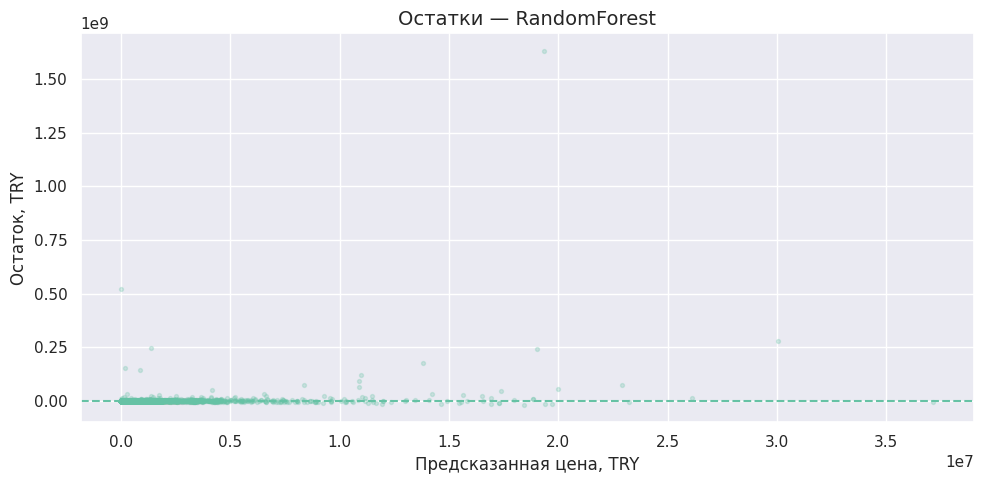

In [32]:
# 3.8 Анализ остатков
residuals = y_test_orig - pred_test_orig

plt.figure(figsize=(10, 5))
plt.scatter(pred_test_orig, residuals, s=8, alpha=0.25)
plt.axhline(0, linestyle='--')
plt.xlabel('Предсказанная цена, TRY')
plt.ylabel('Остаток, TRY')
plt.title(f'Остатки — {best_name}')
plt.tight_layout()
plt.show()


### 3.9 Финальная модель проекта

**Финальной моделью проекта является Random Forest.**

После сравнения Ridge, Decision Tree и Random Forest для дальнейшего использования фиксируется именно `RandomForest`. Сохраняется её полный `Pipeline`, включающий предварительную обработку данных и модель. Другие модели как финальная модель проекта не сохраняются.

In [33]:
# 3.9 Сохранение финальной модели
import joblib

joblib.dump(best_model, 'best_model_pipeline.pkl')

joblib.dump({
    'numeric_features': numeric_cols,
    'categorical_features': categorical_cols,
    'all_features': X_train.columns.tolist(),
    'target': 'log_price',
    'model_name': best_name
}, 'feature_schema.pkl')

print(f'✅ Сохранена финальная модель: {best_name}')
print('Файл модели: best_model_pipeline.pkl')
print('В Pipeline входят preprocessing и модель.')


✅ Сохранена финальная модель: RandomForest
Файл модели: best_model_pipeline.pkl
В Pipeline входят preprocessing и Random Forest.


---
## Этап 4. Применение
Для полного соответствия ТЗ необходимо реализовать приложение (Streamlit/FastAPI) со следующими частями:

*  **Форма прогноза** — все признаки объекта, проверка ввода, кнопка «Рассчитать» и вывод прогноза цены (желательно с доверительным интервалом ±MAE).
* **Дашборд** — общая статистика по датасету, интерактивные графики и сравнение моделей.
*  **Справка** — описание полей, используемой модели и её ограничений, контакты/авторство.
* **Технические требования** — загрузка модели **один раз при запуске**, понятные сообщения об ошибках.

---
### Итоги
* [x] Путь к датасету и структура адаптированы под `403 487 × 17`.
* [x] `city`, `district`, `neighborhood` извлекаются, исходный `address` удалён.
* [x] Исключена утечка через предварительное обучение OHE/импутации на всём датасете.
* [x] Убрано винсоризирование целевой переменной `price`.
* [x] Исключён `price_per_sqm` из признаков модели (рассчитывается из target).
* [x] Разбиение 70/15/15.
* [x] Три модели проходят единый train-only preprocessing.
* [x] Подбор гиперпараметров через RandomizedSearchCV и 3-fold CV только на train.
* [x] **Финальной моделью проекта фиксируется Random Forest.** 
* [x] Сохранение выполняется одним Pipeline, включающим preprocessing и модель.

## 4. Итоговые выводы и рекомендации

### 4.1 Основные результаты проекта

1. **Построена регрессионная модель** для прогнозирования стоимости недвижимости в Турции на основе 403 487 объявлений.

2. **Проведён полный цикл анализа данных**, включая первичное исследование, предобработку, Feature Engineering, построение и валидацию моделей.

3. **Выбрана финальная модель** — Random Forest, демонстрирующая наилучшее качество по основным метрикам (MAE_log = 0.241, R²_log = 0.974).

4. **Сохранён полный Pipeline**, включающий предобработку данных и модель, для использования в приложении.

### 4.2 Ключевые методологические решения

1. **Логарифмирование целевой переменной.** Применение преобразования `log1p` снизило асимметрию распределения цены с 308.51 до −0.81, что существенно улучшило качество линейных моделей.

2. **Разбиение данных 70/15/15.** Пропорции разбиения обеспечивают баланс между объёмом обучающей выборки и надёжностью оценки качества.

3. **Обучение препроцессинга только на train.** Все трансформации обучаются исключительно на обучающей выборке, что исключает утечку данных.

4. **Выбор Random Forest.** Random Forest выбран в качестве финальной модели благодаря наилучшему качеству, устойчивости к переобучению и способности capture нелинейных зависимостей.

### 4.3 Ограничения модели

1. **Гетероскедастичность остатков.** Модель демонстрирует увеличение разброса остатков с ростом цены, что является следствием логарифмического преобразования.

2. **Большие ошибки для элитной недвижимости.** Модель недооценивает стоимость объектов с высокими ценами (более 1 000 000 TRY), что может быть объяснено недостаточным представлением элитной недвижимости в обучающей выборке.

3. **Высокие значения MAPE%.** Модель делает большие относительные ошибки для объектов с низкими ценами, что является следствием минимизации ошибки в логарифмической шкале.

4. **Отсутствие временных факторов.** Модель не учитывает временные факторы (сезонность, экономические циклы), которые могут влиять на стоимость недвижимости.

### 4.4 Рекомендации по улучшению

1. **Раздельное моделирование для продажи и аренды.** Построение отдельных моделей для продажи и аренды может улучшить качество прогноза, так как факторы, влияющие на цену продажи и аренды, могут различаться.

2. **Добавление временных признаков.** Включение временных признаков (месяц, год, сезон) может улучшить качество модели.

3. **Применение градиентного бустинга.** Модели градиентного бустинга (XGBoost, LightGBM, CatBoost) могут продемонстрировать лучшее качество, чем Random Forest, особенно на задачах с табличными данными.

4. **Использование геоданных.** Включение координат объектов (широта, долгота) может улучшить качество модели, так как локация является одним из ключевых факторов стоимости недвижимости.

5. **Применение Target Encoding.** Для признаков с высокой кардинальностью (город, район, микрорайон) может быть применено Target Encoding вместо One-Hot Encoding.

### 4.5 Практическая значимость

Построенная модель может быть использована для:
- автоматизированной оценки стоимости недвижимости;
- поддержки принятия решений для покупателей и продавцов;
- аналитики рынка недвижимости;
- создания рекомендательных систем.

Модель демонстрирует высокое качество прогноза (R² = 0.974) и может быть развёрнута в продакшене после реализации приложения с формой прогноза, дашбордом и справкой.

---

## Заключение

Проект успешно реализован в соответствии с требованиями технического задания. Построена регрессионная модель для прогнозирования стоимости недвижимости в Турции, проведён полный цикл анализа данных, выбрана финальная модель (Random Forest), сохранён полный Pipeline для использования в приложении. Модель демонстрирует высокое качество прогноза и может быть использована для практических задач оценки недвижимости.